# Imager Validation: NOAA-20 ATMS

This notebook validates TAT-C's representation of horizontal imagers against an operational cross-track scanning instrument: the [Advanced Technology Microwave Sounder (ATMS)](https://www.star.nesdis.noaa.gov/jpss/ATMS.php) aboard NOAA-20 (JPSS-1). ATMS is a 22-channel microwave radiometer (23 to 183 GHz). Its antenna scans perpendicular to the flight direction, sampling 96 Earth views spaced 1.11 deg apart every 8/3 s, with beam centers up to 52.725 deg from nadir (a swath about 2,600 km wide).

TAT-C represents a nadir-pointing imager in one of two ways:

* an `Instrument` with a **field of regard**, the cone of view angles from nadir within which a point can be observed. Its instantaneous footprint is a circle, and its swath is the band that circle traces.
* a `PointedInstrument` with cross-track and along-track **fields of view**, a rectangular (or elliptical) view that can be divided into a grid of pixels.

TAT-C does not model the scan mechanism. Every pixel in a view is observed at the same instant, and the along-track field of view stands in for the time the instrument takes to sweep the ground: tailored to an analysis time step, consecutive views tile the swath. The comparison asks five questions:

1. **Orbit.** Does TAT-C's propagation of the operational two-line element (TLE) set reproduce NOAA-20's position?
2. **Scan geometry.** Which view angles and which along-track reference direction reproduce ATMS's actual scan?
3. **Beam geolocation.** How closely do TAT-C's pixel positions (`collect_ground_pixels`) match ATMS's beam centers, and how much of the difference comes from scan timing, which TAT-C does not model?
4. **Swath.** Does TAT-C's swath (`compute_ground_track`) match the area ATMS samples, for time steps from one scan to two minutes?
5. **Daily observations.** Does `collect_observations` predict which points ATMS observes in a day, when, and at what elevation angle?

A companion notebook, [Imager Validation: NOAA-20 VIIRS](ValidateImagerVIIRS.ipynb), repeats the exercise for a visible and infrared imager on the same spacecraft.

## Reference Data

NOAA distributes Joint Polar Satellite System (JPSS) data through the [NOAA Open Data Dissemination](https://www.noaa.gov/nodd) program. The NOAA-20 archive is public on AWS ([`noaa-nesdis-n20-pds`](https://registry.opendata.aws/noaa-jpss/)) and requires no account. Two products are used:

* **ATMS SDR geolocation** (`ATMS-SDR-GEO`, files `GATMO_*`): one HDF5 file per 32 s granule of 12 scans. For each scan, it gives the start and middle times and the spacecraft's Earth-fixed position and velocity at the middle time. For each beam, it gives the geodetic latitude, longitude, and height of the beam center and the satellite zenith angle.
* **Two-line elements** (`TLE-AUX`): the element sets used by the JPSS ground system, one per day with an epoch at 00:00 UTC.

One full day (2 October 2026; 2,700 granules, about 0.3 GB) is downloaded with `requests` and read with `h5py` (`pip install h5py`). The first run takes a few minutes; reduced arrays are cached in a local `data/jpss` directory, so later runs are fast.

In [1]:
import concurrent.futures
import io
import re
from datetime import datetime, timezone
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import requests

DATA_DIR = Path("data") / "jpss"
DATA_DIR.mkdir(parents=True, exist_ok=True)
BUCKET = "https://noaa-nesdis-n20-pds.s3.amazonaws.com/"
DAY = datetime(2026, 10, 2, tzinfo=timezone.utc)


def list_keys(prefix):
    """Keys of all objects in the bucket with a prefix."""
    keys, token = [], None
    while True:
        params = {"list-type": "2", "prefix": prefix}
        if token:
            params["continuation-token"] = token
        listing = requests.get(BUCKET, params=params, timeout=60).text
        keys += re.findall(r"<Key>(.*?)</Key>", listing)
        match = re.search(r"<NextContinuationToken>(.*?)</NextContinuationToken>", listing)
        if match is None:
            return keys
        token = match.group(1)


def fetch(key):
    """Download an object, retrying transient failures."""
    for attempt in range(5):
        try:
            response = requests.get(BUCKET + key, timeout=120)
            response.raise_for_status()
            return response.content
        except requests.RequestException:
            if attempt == 4:
                raise


TLE_FILE = DATA_DIR / f"n20_tle_{DAY:%Y%m%d}.txt"
if not TLE_FILE.exists():
    # the element set with an epoch at the start of the day
    key = next(k for k in list_keys(f"TLE-AUX/{DAY:%Y/%m/%d}/") if f"Z_{DAY:%Y%m%d}000000Z_" in k)
    with h5py.File(io.BytesIO(fetch(key))) as f:
        TLE_FILE.write_text(bytes(f["All_Data/TLE-AUX_All/Dataset_Array_0"][:]).decode().strip() + "\n")
tle = TLE_FILE.read_text().splitlines()

ATMS_FILE = DATA_DIR / f"atms_gatmo_{DAY:%Y%m%d}.npz"
ATMS_FIELDS = [
    "StartTime", "MidTime", "SCPosition", "SCVelocity", "Latitude", "Longitude", "Height",
    "SatelliteZenithAngle", "QF1_ATMSSDRGEO",
]
if not ATMS_FILE.exists():

    def read_granule(key):
        with h5py.File(io.BytesIO(fetch(key))) as f:
            return {field: f["All_Data/ATMS-SDR-GEO_All/" + field][:] for field in ATMS_FIELDS}

    keys = list_keys(f"ATMS-SDR-GEO/{DAY:%Y/%m/%d}/")
    with concurrent.futures.ThreadPoolExecutor(16) as pool:
        granules = list(pool.map(read_granule, keys))
    np.savez_compressed(ATMS_FILE, **{field: np.concatenate([g[field] for g in granules]) for field in ATMS_FIELDS})

atms = dict(np.load(ATMS_FILE))
print(tle[0], tle[1], sep="\n")
pd.Series({"granules": len(atms["MidTime"]) // 12, "scans": len(atms["MidTime"]), "beams per scan": atms["Latitude"].shape[1]})

1 43013U 17073A   26275.00000000  .00000083  00000-0  39562-4 0  2455
2 43013 098.7849 213.5412 0000651 045.7112 319.4843 14.19528658459636


granules           2700
scans             32400
beams per scan       96
dtype: int64

## Setup

Times in JPSS products count microseconds since 1 January 1958 including leap seconds (IDPS Epoch Time, IET); subtracting the 37 leap seconds in effect gives UTC. A few scans flagged by the quality flag or with missing (fill value) beams are excluded.

NOAA-20 is modeled with the operational TLE. TAT-C's ATMS model has 96 pixels spaced 1.11 deg, so the cross-track field of view is 96 x 1.11 = 106.56 deg, and the field of regard spans the outermost beam centers, 2 x 52.725 = 105.45 deg. TAT-C numbers pixels starting from the right of the direction of motion, whereas ATMS numbers beams starting from the left, so TAT-C pixel `95 - j` corresponds to ATMS beam `j`.

Helper functions convert between geodetic and Earth-fixed coordinates and decompose horizontal offsets into components along and to the right of a reference direction.

In [2]:
from datetime import timedelta

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from pyproj import Transformer
from scipy.optimize import least_squares
from scipy.spatial import cKDTree
from skyfield.api import wgs84
from skyfield.framelib import itrs

from tatc.analysis import collect_ground_pixels, collect_observations, compute_ground_track
from tatc.constants import EARTH_MEAN_RADIUS, EARTH_ROTATION_RATE
from tatc.generation import generate_points_fibonacci_lattice
from tatc.schemas import GeneralPerturbationsOrbit, Instrument, Point, PointedInstrument, Satellite
from tatc.utils import (
    VelocityFrame,
    compute_apoapsis_radius,
    compute_field_of_regard,
    compute_min_elevation_angle,
    field_of_regard_to_swath_width,
)

IET_EPOCH = pd.Timestamp("1958-01-01", tz="UTC")
LEAP_SECONDS = 37
N_BEAMS, SPACING, SCAN_PERIOD = 96, 1.11, 8 / 3  # -, deg, s
EDGE = (N_BEAMS - 1) / 2 * SPACING  # deg


def iet_to_utc(iet):
    return IET_EPOCH + pd.to_timedelta(np.asarray(iet) - LEAP_SECONDS * 1_000_000, unit="us")


good = (atms["QF1_ATMSSDRGEO"] == 0) & np.all(np.abs(atms["Latitude"]) <= 90, axis=1)
t_start, t_mid = iet_to_utc(atms["StartTime"][good]), iet_to_utc(atms["MidTime"][good])
sc_pos, sc_vel = atms["SCPosition"][good].astype(float), atms["SCVelocity"][good].astype(float)
beam_lat, beam_lon = atms["Latitude"][good].astype(float), atms["Longitude"][good].astype(float)
beam_height = atms["Height"][good].astype(float)
beam_zenith = atms["SatelliteZenithAngle"][good].astype(float)

noaa20 = Satellite(name="NOAA-20", orbit=GeneralPerturbationsOrbit.from_tle(tle))
orbit = noaa20.orbit.to_gp_orbit()
atms_pixels = PointedInstrument(
    name="ATMS",
    field_of_regard=2 * EDGE,
    cross_track_field_of_view=N_BEAMS * SPACING,
    along_track_field_of_view=SPACING,
    is_rectangular=True,
    cross_track_pixels=N_BEAMS,
)

TO_ECEF = Transformer.from_crs("EPSG:4979", "EPSG:4978", always_xy=True)
TO_GEODETIC = Transformer.from_crs("EPSG:4978", "EPSG:4979", always_xy=True)


def ecef(lon, lat, height=0.0):
    """Earth-fixed position (m) of geodetic coordinates, stacked on the last axis."""
    return np.stack(TO_ECEF.transform(lon, lat, np.broadcast_to(height, np.shape(lon))), axis=-1)


def up(lon, lat):
    """Geodetic up unit vector, stacked on the last axis."""
    lon, lat = np.radians(lon), np.radians(lat)
    return np.stack([np.cos(lat) * np.cos(lon), np.cos(lat) * np.sin(lon), np.sin(lat)], axis=-1)


def normalize(x):
    return x / np.linalg.norm(x, axis=-1, keepdims=True)


def along_right(lon, lat, offset, direction):
    """Components (km) of Earth-fixed offsets along and to the right of the horizontal projection of a direction at a location."""
    u = up(lon, lat)
    along = normalize(direction - np.sum(direction * u, axis=-1, keepdims=True) * u)
    right = np.cross(along, u)
    return np.sum(offset * along, axis=-1) / 1e3, np.sum(offset * right, axis=-1) / 1e3


def inertial_velocity(position, velocity):
    """Inertial velocity expressed in Earth-fixed coordinates."""
    return velocity + EARTH_ROTATION_RATE * np.stack(
        [-position[..., 1], position[..., 0], np.zeros(position.shape[:-1])], axis=-1
    )


def summarize(x):
    """Summary statistics of a residual sample."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return pd.Series(
        {
            "n": x.size,
            "median": np.median(x),
            "p95 |x|": np.percentile(np.abs(x), 95),
            "max |x|": np.abs(x).max(),
        }
    )


def binned(x, y, edges, q=(5, 50, 95)):
    """Percentiles of y in bins of x."""
    i = np.digitize(x, edges) - 1
    return np.array([np.percentile(y[i == k], q) if np.any(i == k) else [np.nan] * len(q) for k in range(len(edges) - 1)])


BLUE, ORANGE, AQUA, GRAY, INK = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b"
plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e5e0",
        "grid.linewidth": 0.6,
    }
)
pd.Series(
    {
        "scans used": int(good.sum()),
        "scans excluded": int((~good).sum()),
        "first scan (UTC)": t_start[0],
        "last scan (UTC)": t_start[-1],
        "beam height range (m)": f"{beam_height.min():.0f} to {beam_height.max():.0f}",
    }
)

scans used                                          32394
scans excluded                                          6
first scan (UTC)         2026-10-02 00:00:08.351410+00:00
last scan (UTC)          2026-10-02 23:59:57.684739+00:00
beam height range (m)                          -107 to 85
dtype: object

Beam heights range only from about -100 to +85 m, and are about -30 m over the Himalaya: ATMS beam centers lie on the geoid rather than on the terrain. TAT-C projects pixels onto the WGS 84 ellipsoid (zero elevation); the resulting difference is at most 0.2 km at the swath edge and is ignored.

## Test 1: Orbit

TAT-C's propagated position is compared with the spacecraft position reported at the middle time of every tenth scan, with residuals decomposed along the reported velocity, to its right, and radially.

In [3]:
i1 = np.arange(0, len(t_mid), 10)
p1, v1 = orbit.get_orbit_track(list(t_mid[i1])).frame_xyz_and_velocity(itrs)
offset1 = np.array(p1.m).T - sc_pos[i1]
radial1 = normalize(sc_pos[i1])
along1 = normalize(sc_vel[i1] - np.sum(sc_vel[i1] * radial1, axis=-1, keepdims=True) * radial1)
test1 = pd.DataFrame(
    {
        "along-track (km)": summarize(np.sum(offset1 * along1, axis=-1) / 1e3),
        "cross-track, right (km)": summarize(np.sum(offset1 * np.cross(along1, radial1), axis=-1) / 1e3),
        "radial (km)": summarize(np.sum(offset1 * radial1, axis=-1) / 1e3),
        "velocity (m/s)": summarize(np.linalg.norm(np.array(v1.m_per_s).T - sc_vel[i1], axis=-1)),
    }
).T
test1.round(3)

,n,median,p95 |x|,max |x|
along-track (km),3240.0,-0.070,1.115,1.253
"cross-track, right (km)",3240.0,-0.007,0.416,0.543
radial (km),3240.0,0.008,0.327,0.406
velocity (m/s),3240.0,0.588,0.984,1.109


The TLE reproduces NOAA-20's position to about 1 km along track (95th percentile) over the day, and much better radially and cross-track, which is small compared with an ATMS beam footprint (about 32 km at nadir for the 2.2 deg beams).

## Test 2: Scan Geometry

This test uses only the reference data: the reported spacecraft position and velocity and the beam centers.

ATMS samples each beam for about 18 ms, so the 96 beams of a scan span about 1.7 s, centered on the scan's middle time. If the samples are contiguous, beam `j` is centered at `(j - 47.5) * dt` from the middle time, with `dt = 2 * (MidTime - StartTime) / 96`. Each beam's line of sight is the vector from the spacecraft position at that time (extrapolated linearly from the reported position and velocity) to the beam center.

### Scan Angles

The scan angle of each beam is the angle between its line of sight and the geodetic nadir, positive to the left of the direction of motion (TAT-C's positive roll direction). TAT-C rotates a rolled view rigidly, so a pixel's angle from nadir is the sum of the roll angle and the pixel's angular offset from the view center; the measured angles are fit with this model to find the effective spacing and roll angle.

In [4]:
dt_beam = 2 * np.median(atms["MidTime"][good] - atms["StartTime"][good]) / 1e6 / N_BEAMS
beam_offset = (np.arange(N_BEAMS) - (N_BEAMS - 1) / 2) * dt_beam  # s from the middle time
beam_xyz = ecef(beam_lon, beam_lat, beam_height)
beam_sc = sc_pos[:, np.newaxis] + sc_vel[:, np.newaxis] * beam_offset[:, np.newaxis]
sc_lon, sc_lat, _ = TO_GEODETIC.transform(beam_sc[..., 0], beam_sc[..., 1], beam_sc[..., 2])
los = normalize(beam_xyz - beam_sc)
side = np.where(np.arange(N_BEAMS) < N_BEAMS / 2, 1, -1)  # beams 0-47 are to the left
scan_angle = side * np.degrees(np.arccos(np.sum(los * -up(sc_lon, sc_lat), axis=-1)))
measured = np.median(scan_angle, axis=0)
nominal = ((N_BEAMS - 1) / 2 - np.arange(N_BEAMS)) * SPACING


def model(params, index=np.arange(N_BEAMS)):
    spacing, roll = params
    return roll + spacing * ((N_BEAMS - 1) / 2 - index)


fit = least_squares(lambda params: model(params) - measured, [SPACING, 0]).x
fitted_spacing, fitted_roll = fit
pd.Series(
    {
        "sample interval dt (ms)": dt_beam * 1e3,
        "nominal spacing (deg)": SPACING,
        "fitted spacing (deg)": fitted_spacing,
        "fitted roll (deg)": fitted_roll,
        "fit residual, max |x| (deg)": np.abs(model(fit) - measured).max(),
        "scan-to-scan std. dev., median (deg)": np.median(np.std(scan_angle, axis=0)),
        "left edge, measured (deg)": measured[0],
        "right edge, measured (deg)": measured[-1],
        "field of regard, measured (deg)": measured[0] - measured[-1],
    }
).round(4)

sample interval dt (ms)                  17.6426
nominal spacing (deg)                     1.1100
fitted spacing (deg)                      1.1120
fitted roll (deg)                         0.0398
fit residual, max |x| (deg)               0.0188
scan-to-scan std. dev., median (deg)      0.0063
left edge, measured (deg)                52.8419
right edge, measured (deg)              -52.7972
field of regard, measured (deg)         105.6392
dtype: float64

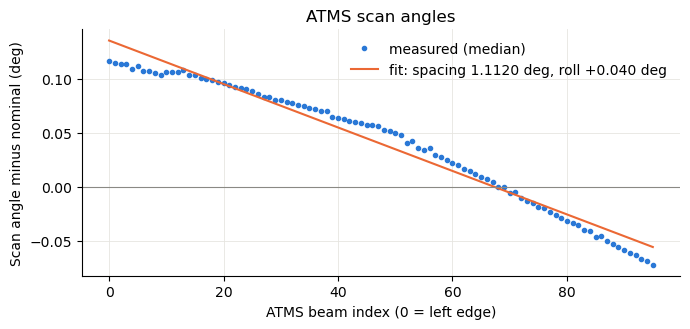

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(np.arange(N_BEAMS), measured - nominal, color=BLUE, marker="o", ms=3, lw=0, label="measured (median)")
ax.plot(np.arange(N_BEAMS), model(fit) - nominal, color=ORANGE, label=f"fit: spacing {fitted_spacing:.4f} deg, roll {fitted_roll:+.3f} deg")
ax.axhline(0, color=GRAY, lw=0.8)
ax.set(xlabel="ATMS beam index (0 = left edge)", ylabel="Scan angle minus nominal (deg)", title="ATMS scan angles")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

The measured scan angles are stable from scan to scan (a standard deviation of about 0.006 deg) and differ from the nominal 1.11 deg grid by up to 0.12 deg at the edges. The rigid-rotation model fits them to within 0.02 deg with a spacing of 1.112 deg and a roll of 0.04 deg to the left. The residual is systematic: the measured asymmetry is about 0.05 deg near nadir but only 0.02 deg at the edges, so it is not exactly a rotation of the scan (it resembles an offset of the view in the plane at nadir instead). The measured field of regard is about 0.2 deg wider than the nominal 105.45 deg. At the swath edge, where the line of sight meets the ground at a satellite zenith angle of about 64 deg, 0.1 deg corresponds to about 6 km on the ground.

### Scan Plane Orientation

TAT-C orients a view relative to a velocity vector: the along-track axis is parallel to the velocity, and the cross-track axis is perpendicular to it and to nadir. By default (`VelocityFrame.EARTH_FIXED`), the velocity is relative to the rotating Earth, so the view is aligned with the ground track, as for a yaw-steered spacecraft. NOAA-20 does not steer in yaw: its attitude follows the orbital (inertial) frame. Earth's rotation turns the ground track by up to about 4 deg relative to the orbit plane, most at the equator and least at the poles.

For every tenth scan, the plane through the beams' lines of sight is fit by a singular value decomposition, and its normal (the direction the scan plane faces) is compared with the horizontal direction of the Earth-fixed and inertial velocity (with yaw angles positive counterclockwise viewed from above).

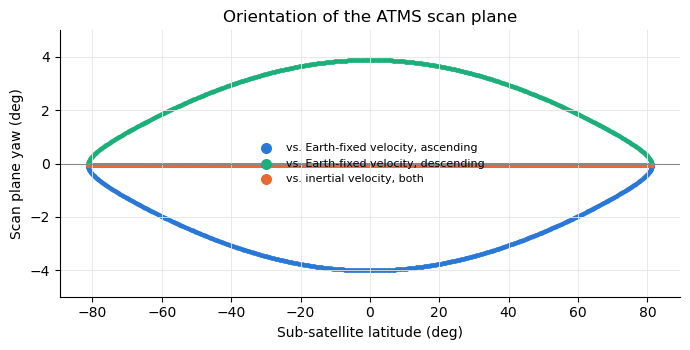

,n,median,p95 |x|,max |x|
yaw vs. Earth-fixed velocity (deg),3240.0,-0.144,3.963,4.012
yaw vs. inertial velocity (deg),3240.0,-0.060,0.060,0.061
line of sight out of plane (deg),311040.0,0.012,0.027,0.039


In [6]:
i2 = np.arange(0, len(t_mid), 10)
normal = np.array([np.linalg.svd(los[k])[2][-1] for k in i2])
normal *= np.sign(np.sum(normal * sc_vel[i2], axis=-1))[:, np.newaxis]
sub_lon, sub_lat, _ = TO_GEODETIC.transform(sc_pos[i2, 0], sc_pos[i2, 1], sc_pos[i2, 2])
u2 = up(sub_lon, sub_lat)


def yaw(direction, reference):
    """Signed angle (deg) from the horizontal projection of a reference direction to that of a direction."""
    a = normalize(reference - np.sum(reference * u2, axis=-1, keepdims=True) * u2)
    b = normalize(direction - np.sum(direction * u2, axis=-1, keepdims=True) * u2)
    return np.degrees(np.arctan2(np.sum(np.cross(a, b) * u2, axis=-1), np.sum(a * b, axis=-1)))


yaw_earth_fixed = yaw(normal, sc_vel[i2])
yaw_inertial = yaw(normal, inertial_velocity(sc_pos[i2], sc_vel[i2]))
ascending = sc_vel[i2, 2] > 0
out_of_plane = np.degrees(np.abs(np.arcsin(np.einsum("kjc,kc->kj", los[i2], normal))))

fig, ax = plt.subplots(figsize=(7, 3.6))
for mask, color, label in [(ascending, BLUE, "ascending"), (~ascending, AQUA, "descending")]:
    ax.scatter(sub_lat[mask], yaw_earth_fixed[mask], s=3, color=color, label=f"vs. Earth-fixed velocity, {label}")
ax.scatter(sub_lat, yaw_inertial, s=3, color=ORANGE, label="vs. inertial velocity, both")
ax.axhline(0, color=GRAY, lw=0.8)
ax.set(xlabel="Sub-satellite latitude (deg)", ylabel="Scan plane yaw (deg)", title="Orientation of the ATMS scan plane", ylim=(-5, 5))
ax.legend(frameon=False, fontsize=8, markerscale=4, loc="center")
fig.tight_layout()
plt.show()
pd.DataFrame(
    {
        "yaw vs. Earth-fixed velocity (deg)": summarize(yaw_earth_fixed),
        "yaw vs. inertial velocity (deg)": summarize(yaw_inertial),
        "line of sight out of plane (deg)": summarize(out_of_plane),
    }
).T.round(3)

The lines of sight of each scan lie in a plane (to within about 0.03 deg) that faces the inertial velocity at all latitudes, to within a constant 0.06 deg, whereas the Earth-fixed velocity is rotated by up to 4 deg, with opposite signs on ascending and descending passes. A `PointedInstrument` with `velocity_frame=VelocityFrame.INERTIAL` reproduces this orientation; the Earth-fixed default would rotate the scan line about nadir, displacing the swath edges (about 1,280 km from the ground track) by up to about 85 km along track.

## Test 3: Beam Geolocation

TAT-C pixel positions from `collect_ground_pixels`, at the middle time of every hundredth scan, are compared with the ATMS beam centers. Four configurations isolate the contributions of the along-track reference direction, the scan angles, and scan timing:

* **Nominal, Earth-fixed:** 1.11 deg spacing with TAT-C's default velocity frame.
* **Nominal, inertial:** the same with `velocity_frame=VelocityFrame.INERTIAL`.
* **Fitted, inertial:** the spacing and roll angle fitted in Test 2.
* **Fitted, inertial, sample times:** the same, but with each pixel projected at its own beam's sample time rather than all at the scan's middle time. TAT-C does not do this; it is computed here (with `PointedInstrument.compute_projected_pixel_position`) to quantify the effect of scan timing.

Residuals (TAT-C minus ATMS) are decomposed along and to the right of the ground track (the horizontal direction of the reported Earth-fixed velocity) at each beam center.

In [7]:
i3 = np.arange(0, len(t_mid), 100)
times3 = list(t_mid[i3])
configs = {
    "nominal, Earth-fixed": atms_pixels,
    "nominal, inertial": atms_pixels.model_copy(update={"velocity_frame": VelocityFrame.INERTIAL}),
    "fitted, inertial": atms_pixels.model_copy(
        update={
            "velocity_frame": VelocityFrame.INERTIAL,
            "cross_track_field_of_view": N_BEAMS * fitted_spacing,
            "roll_angle": fitted_roll,
        }
    ),
}
pixels = {}
for name, instrument in configs.items():
    track = collect_ground_pixels(noaa20.model_copy(update={"instruments": [instrument]}), times3)
    # one row per time and pixel (TAT-C pixel 0 on the right); reverse to ATMS beam order
    pixels[name] = (
        track.geometry.x.to_numpy().reshape(len(i3), N_BEAMS)[:, ::-1],
        track.geometry.y.to_numpy().reshape(len(i3), N_BEAMS)[:, ::-1],
    )
lon3, lat3 = np.zeros((len(i3), N_BEAMS)), np.zeros((len(i3), N_BEAMS))
for j in range(N_BEAMS):
    position = configs["fitted, inertial"].compute_projected_pixel_position(
        orbit.get_orbit_track([t + timedelta(seconds=beam_offset[j]) for t in times3]), N_BEAMS - 1 - j, 0
    )
    lon3[:, j], lat3[:, j] = position.longitude.degrees, position.latitude.degrees
pixels["fitted, inertial, sample times"] = (lon3, lat3)

residuals3 = {
    name: along_right(beam_lon[i3], beam_lat[i3], ecef(lon, lat) - ecef(beam_lon[i3], beam_lat[i3]), sc_vel[i3, np.newaxis])
    for name, (lon, lat) in pixels.items()
}
pd.DataFrame(
    {
        (name, component): summarize(values).loc[["median", "p95 |x|", "max |x|"]]
        for name, (along, right) in residuals3.items()
        for component, values in [("along", along), ("right", right), ("horizontal", np.hypot(along, right))]
    }
).T.round(2)

median  p95 |x|  max |x|
nominal, Earth-fixed           along        -0.51    63.24    92.44
                               right         0.78     3.97     8.75
                               horizontal   15.69    63.32    92.55
nominal, inertial              along        -0.68     4.88     6.01
                               right         0.78     5.08     8.75
                               horizontal    3.18     6.84    10.45
fitted, inertial               along        -0.68     4.89     5.57
                               right        -0.02     1.02     2.52
                               horizontal    2.92     4.95     5.92
fitted, inertial, sample times along        -0.41     1.33     2.15
                               right        -0.02     1.01     2.53
                               horizontal    0.71     1.53     2.83

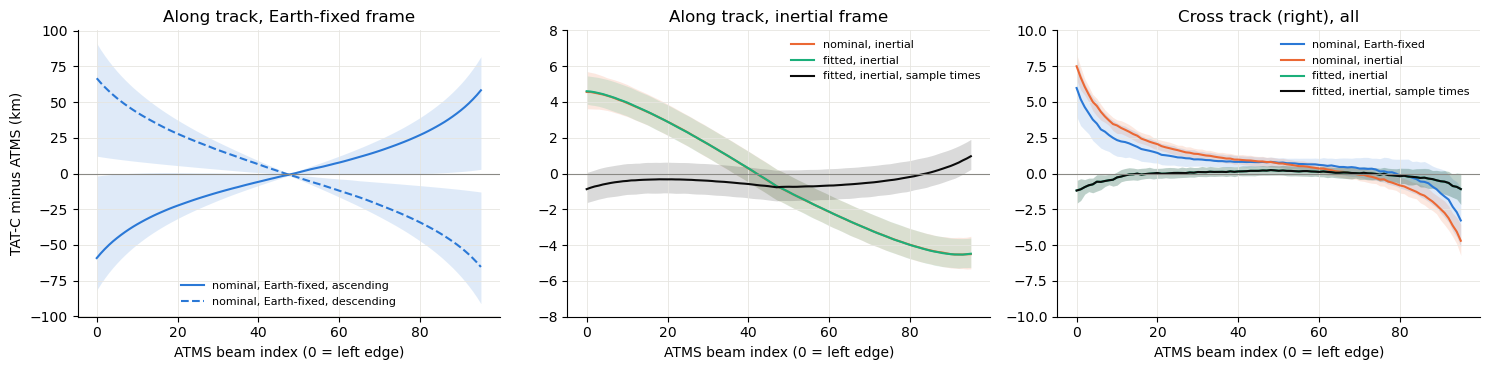

In [8]:
ascending3 = sc_vel[i3, 2] > 0
colors3 = dict(zip(residuals3, [BLUE, ORANGE, AQUA, INK]))


def band(ax, values, color, label, ls="-"):
    q = np.percentile(values, [5, 50, 95], axis=0)
    ax.fill_between(np.arange(N_BEAMS), q[0], q[2], color=color, alpha=0.15, lw=0)
    ax.plot(np.arange(N_BEAMS), q[1], color=color, ls=ls, label=label)


fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharex=True)
along, right = residuals3["nominal, Earth-fixed"]
band(axes[0], along[ascending3], BLUE, "nominal, Earth-fixed, ascending")
band(axes[0], along[~ascending3], BLUE, "nominal, Earth-fixed, descending", ls="--")
for name, (along, right) in residuals3.items():
    if name != "nominal, Earth-fixed":
        band(axes[1], along, colors3[name], name)
    band(axes[2], right, colors3[name], name)
axes[0].set(ylabel="TAT-C minus ATMS (km)", title="Along track, Earth-fixed frame")
axes[1].set(title="Along track, inertial frame", ylim=(-8, 8))
axes[2].set(title="Cross track (right), all", ylim=(-10, 10))
for ax in axes:
    ax.set_xlabel("ATMS beam index (0 = left edge)")
    ax.axhline(0, color=GRAY, lw=0.8)
    ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

Lines show medians and bands the 5th to 95th percentiles.

* **Along-track reference direction.** With TAT-C's default Earth-fixed velocity frame, the along-track residual grows across the scan to about 60 km (median) and 90 km (95th percentile) at the edges, with opposite signs on ascending and descending passes. The inertial velocity frame removes this error.
* **Scan timing.** With all pixels at the scan's middle time, the remaining along-track residual is a tilt across the scan of about 4.5 km at each edge: ATMS samples its left edge first and its right edge last, about 0.85 s before and after the middle time, while NOAA-20's ground track advances about 6.6 km/s. Projecting each pixel at its sample time removes the tilt. This is the integration time that TAT-C's single-instant view does not resolve.
* **Scan angles.** With the nominal spacing, the cross-track residual grows to about 5 to 8 km at the edges (TAT-C's swath is narrower), and the fitted spacing and roll reduce it to about 1 km (95th percentile), the remainder reflecting the residual of the fit in Test 2.

With all three accounted for, TAT-C reproduces the ATMS beam centers to 0.7 km (median) and 1.5 km (95th percentile) everywhere in the swath, comparable to the orbit error of Test 1.

## Test 4: Swath

### Swath Width

For a nadir `Instrument`, TAT-C converts the field of regard to a swath width with `field_of_regard_to_swath_width`, assuming a spherical Earth with the mean radius and the satellite's geodetic altitude. `collect_observations` instead finds the minimum elevation angle at which a point is visible, at a conservative altitude (the orbit's apogee radius minus the mean radius), and applies it at the actual altitude; the equivalent swath width is computed with `compute_min_elevation_angle` and `compute_field_of_regard`. The observed swath width is the distance along the surface from the left to the right edge beam, through the intermediate beams.

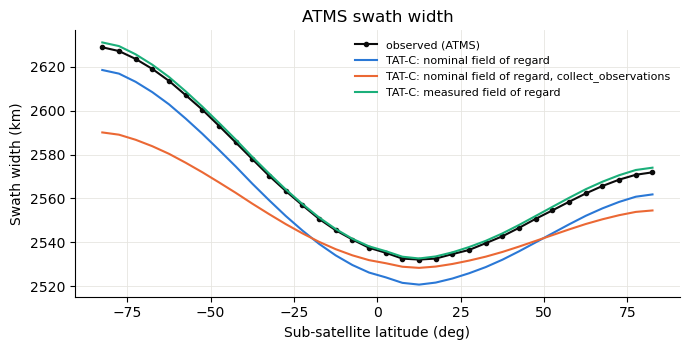

,n,median,p95 |x|,max |x|
nominal field of regard,6479.0,-10.7,13.4,14.7
"nominal field of regard, collect_observations",6479.0,-14.1,38.0,40.5
measured field of regard,6479.0,1.5,3.5,4.1


In [9]:
i4 = np.arange(0, len(t_mid), 5)
observed_width = np.sum(
    np.linalg.norm(np.diff(beam_xyz[i4], axis=1), axis=-1), axis=1
) / 1e3
sub4 = wgs84.geographic_position_of(orbit.get_orbit_track(list(t_mid[i4])))
# as in collect_observations
apogee_altitude = compute_apoapsis_radius(noaa20.orbit.get_semimajor_axis(), noaa20.orbit.get_eccentricity()) - EARTH_MEAN_RADIUS
swath_width = np.vectorize(field_of_regard_to_swath_width)
# the field of regard at the geodetic altitude equivalent to the minimum elevation angle in collect_observations
min_elevation_angle = compute_min_elevation_angle(apogee_altitude, 2 * EDGE)
equivalent_field_of_regard = np.vectorize(compute_field_of_regard)(sub4.elevation.m, min_elevation_angle)
widths = {
    "nominal field of regard": swath_width(sub4.elevation.m, 2 * EDGE) / 1e3,
    "nominal field of regard, collect_observations": swath_width(sub4.elevation.m, equivalent_field_of_regard) / 1e3,
    "measured field of regard": swath_width(sub4.elevation.m, measured[0] - measured[-1]) / 1e3,
}
edges4 = np.arange(-90, 91, 5)
centers4 = (edges4[:-1] + edges4[1:]) / 2
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(centers4, binned(sub4.latitude.degrees, observed_width, edges4)[:, 1], color=INK, marker="o", ms=3, label="observed (ATMS)")
for (name, width), color in zip(widths.items(), [BLUE, ORANGE, AQUA]):
    ax.plot(centers4, binned(sub4.latitude.degrees, width, edges4)[:, 1], color=color, label=f"TAT-C: {name}")
ax.set(xlabel="Sub-satellite latitude (deg)", ylabel="Swath width (km)", title="ATMS swath width")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()
pd.DataFrame({name: summarize(width - observed_width) for name, width in widths.items()}).T.round(1)

NOAA-20's geodetic altitude varies by about 30 km over an orbit, mostly because of Earth's oblateness, so the swath width varies by about 100 km, from about 2,530 km near the equator to about 2,630 km at high southern latitudes. TAT-C's nominal field of regard reproduces this variation but is about 11 km too narrow (median); the measured field of regard (Test 2) agrees to within about 2 km. The equivalent swath in `collect_observations` departs from the field of regard by up to about 30 km: the geodetic altitude exceeds the "conservative" apogee altitude at middle and high latitudes, where the elevation threshold is too strict.

### Swath Area

Over one orbit (starting at 12:00 UTC), the area sampled by ATMS (the union of the quadrilaterals formed by adjacent beam centers on consecutive scans) is compared with the union of TAT-C footprints from `compute_ground_track`, on a 0.1 deg grid:

* a nadir `Instrument` with the nominal field of regard, at a 60 s time step (circular footprints of 2,600 km diameter); and
* a rectangular `PointedInstrument` with the nominal field of regard as its cross-track field of view and the inertial velocity frame, at time steps of 8/3 s (one scan), 32 s (one granule), and 128 s, with the along-track field of view tailored to each time step: the angle subtended at nadir by the ground distance traveled in one time step.

Footprints at the first and last time steps extend beyond the orbit (by up to half the 2,600 km circle for the nadir `Instrument`). To compare swaths rather than these end effects, the comparison is limited to grid cells within 300 km of a beam center sampled at least 128 s after the start and before the end of the orbit.

In [10]:
from shapely import contains_xy, prepare


def unit_vector(lat, lon):
    return up(lon, lat)


beam_unit = unit_vector(beam_lat, beam_lon)
contiguous = np.diff(atms["MidTime"][good]) < 1.5 * SCAN_PERIOD * 1e6


def observed_cells(points, scans):
    """Whether unit vectors lie within a quadrilateral cell of adjacent beams on consecutive scans (a contiguous range of scan indices)."""
    k0, k1 = scans[0], scans[-1]
    cells = beam_unit[k0 : k1 + 1]
    tree = cKDTree(cells.reshape(-1, 3))
    _, nearest = tree.query(points, k=2, workers=-1)
    inside = np.zeros(len(points), dtype=bool)
    for column in range(2):
        k, j = np.divmod(nearest[:, column], N_BEAMS)
        for dk in (-1, 0):
            for dj in (-1, 0):
                kk, jj = k + dk, j + dj
                valid = (kk >= 0) & (kk < len(cells) - 1) & (jj >= 0) & (jj < N_BEAMS - 1)
                kk, jj = np.clip(kk, 0, len(cells) - 2), np.clip(jj, 0, N_BEAMS - 2)
                valid &= contiguous[k0 + kk]
                corners = [cells[kk, jj], cells[kk, jj + 1], cells[kk + 1, jj + 1], cells[kk + 1, jj]]
                signs = np.stack([np.sum(np.cross(a, b) * points, axis=-1) for a, b in zip(corners, corners[1:] + corners[:1])])
                inside |= valid & (np.all(signs >= 0, axis=0) | np.all(signs <= 0, axis=0))
    return inside


STEP4, MARGIN4 = 0.1, 128  # deg, s
lon_grid, lat_grid = np.meshgrid(np.arange(-180 + STEP4 / 2, 180, STEP4), np.arange(-90 + STEP4 / 2, 90, STEP4))
cell_area = np.cos(np.radians(lat_grid)) * (STEP4 * 111.32) ** 2  # km^2
grid_unit = unit_vector(lat_grid.ravel(), lon_grid.ravel())
orbit_start = datetime(2026, 10, 2, 12, tzinfo=timezone.utc)
orbit_period = timedelta(days=1 / float(tle[1][52:63]))
scans4 = np.nonzero((t_mid >= orbit_start) & (t_mid < orbit_start + orbit_period))[0]
first, last = t_mid[scans4[0]].to_pydatetime(), t_mid[scans4[-1]].to_pydatetime()
# grid cells near beams sampled away from the ends of the orbit
distance, nearest = cKDTree(beam_unit[scans4].reshape(-1, 3)).query(grid_unit, workers=-1)
nearest_time = (t_mid[scans4] - t_mid[scans4[0]]).total_seconds().to_numpy()[nearest // N_BEAMS]
compared = (distance < 2 * np.sin(300 / 6371 / 2)) & (nearest_time > MARGIN4) & (nearest_time < (last - first).total_seconds() - MARGIN4)
observed4 = np.zeros(len(grid_unit), dtype=bool)
observed4[compared] = observed_cells(grid_unit[compared], scans4)
ground_speed = 2 * np.pi * 6371.0088e3 / orbit_period.total_seconds()  # m/s, approximate
altitude = float(np.median(sub4.elevation.m))


def swath_area_row(instrument, time_step):
    n = int((last - first).total_seconds() // time_step)
    times = [first + timedelta(seconds=time_step * (i + 0.5)) for i in range(n)]
    geometry = compute_ground_track(noaa20.model_copy(update={"instruments": [instrument]}), times).geometry.iloc[0]
    prepare(geometry)
    predicted = np.zeros(len(grid_unit), dtype=bool)
    predicted[compared] = contains_xy(geometry, lon_grid.ravel()[compared], lat_grid.ravel()[compared])
    area = lambda mask: np.sum(mask * cell_area.ravel()) / 1e6
    return predicted.reshape(lat_grid.shape), {
        "observed (10^6 km^2)": area(observed4),
        "TAT-C (10^6 km^2)": area(predicted),
        "IoU": area(observed4 & predicted) / area(observed4 | predicted),
        "observed only (%)": 100 * area(observed4 & ~predicted) / area(observed4),
        "TAT-C only (%)": 100 * area(predicted & ~observed4) / area(predicted),
    }


swath_rows, swath_maps = {}, {}
swath_maps["field of regard, 60 s"], swath_rows["field of regard, 60 s"] = swath_area_row(
    Instrument(name="ATMS", field_of_regard=2 * EDGE), 60
)
for time_step in [SCAN_PERIOD, 32, 128]:
    along_fov = np.degrees(2 * np.arctan(ground_speed * time_step / 2 / altitude))
    name = f"rectangular, {time_step:.3g} s ({along_fov:.2f} deg along track)"
    swath_maps[name], swath_rows[name] = swath_area_row(
        PointedInstrument(
            name="ATMS",
            field_of_regard=2 * EDGE,
            cross_track_field_of_view=2 * EDGE,
            along_track_field_of_view=along_fov,
            is_rectangular=True,
            velocity_frame=VelocityFrame.INERTIAL,
        ),
        time_step,
    )
observed4 = observed4.reshape(lat_grid.shape)
pd.DataFrame(swath_rows).T.round(3)

,observed (10^6 km^2),TAT-C (10^6 km^2),IoU,observed only (%),TAT-C only (%)
"field of regard, 60 s",98.706,97.955,0.988,0.988,0.229
"rectangular, 2.67 s (1.20 deg along track)",98.706,98.061,0.993,0.654,0.000
"rectangular, 32 s (14.33 deg along track)",98.706,98.184,0.994,0.551,0.021
"rectangular, 128 s (53.39 deg along track)",98.706,99.293,0.989,0.272,0.861


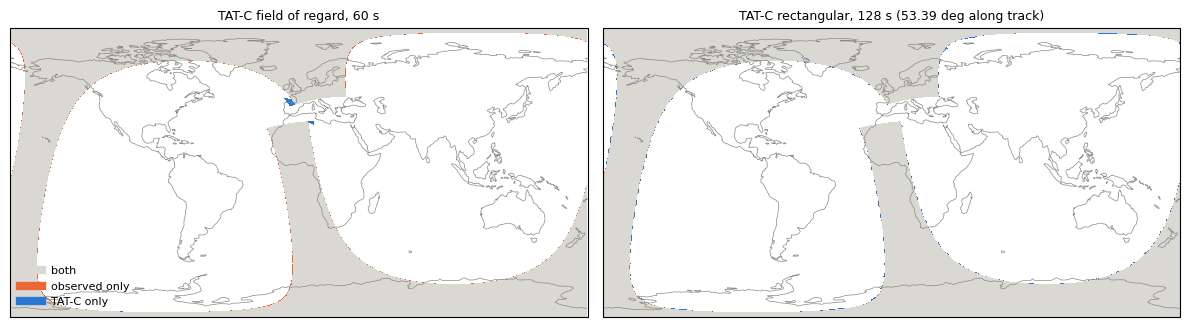

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), subplot_kw={"projection": ccrs.PlateCarree()})
for ax, name in zip(axes, [list(swath_maps)[0], list(swath_maps)[-1]]):
    predicted = swath_maps[name]
    category = np.where(observed4 & predicted, 1, np.where(observed4, 2, np.where(predicted, 3, 0))).astype(float)
    category[~compared.reshape(lat_grid.shape)] = 0
    ax.pcolormesh(
        lon_grid, lat_grid, np.ma.masked_equal(category, 0),
        cmap=plt.matplotlib.colors.ListedColormap(["#d9d8d3", ORANGE, BLUE]), vmin=0.5, vmax=3.5,
        transform=ccrs.PlateCarree(), shading="auto",
    )
    ax.coastlines(color=GRAY, linewidth=0.5)
    ax.set_global()
    ax.set_title(f"TAT-C {name}", fontsize=9)
axes[0].plot([], [], color="#d9d8d3", lw=6, label="both")
axes[0].plot([], [], color=ORANGE, lw=6, label="observed only")
axes[0].plot([], [], color=BLUE, lw=6, label="TAT-C only")
axes[0].legend(frameon=False, loc="lower left", fontsize=8)
fig.tight_layout()
plt.show()

All configurations reproduce the area sampled over one orbit with an intersection over union (IoU) of 0.99. The differences are thin slivers along the swath edges, mostly area observed but not predicted, consistent with TAT-C's slightly narrow nominal swath (above), plus a small patch where the start and end of the orbit overlap. Tailoring the along-track field of view to the time step makes consecutive rectangular footprints tile the swath at every time step tested, so the time step can be chosen for computational cost: one scan (8/3 s) takes several minutes for an orbit, while 32 s or longer takes seconds. At 128 s, footprints spanning 53 deg along track begin to bulge beyond the swath edges (TAT-C only, 0.9%), because the corners of a rectangle in the tangent plane at nadir project farther from the ground track than its center line.

## Test 5: Daily Observations

Finally, `collect_observations`, which finds continuous-time access periods rather than sampling at time steps, is evaluated for 2,598 points on a Fibonacci lattice with a typical spacing of 500 km.

**Observed.** A point is observed on a pass if it lies within a quadrilateral cell of beam centers (as in Test 4). Beam centers within 60 km of each point are grouped into passes (gaps longer than 20 minutes); for each pass, the observation time is interpolated between the two scans that straddle the point, and the elevation angle is computed from the reported spacecraft position at that time.

**Predicted.** Three instruments are compared, each with the nominal field of regard: a nadir `Instrument`, and rectangular `PointedInstrument`s with the cross-track field of view equal to the field of regard and the along-track field of view tailored to one scan, in either velocity frame. For a `PointedInstrument`, `collect_observations` reports the time at which the view sweeps over the point as the observation epoch; for a nadir `Instrument`, it reports the midpoint of the access period, the time of closest approach.

Predicted and observed passes of the same point are matched if their times differ by less than 10 minutes.

In [12]:
points5 = generate_points_fibonacci_lattice(500e3)
point_unit = unit_vector(points5.geometry.y.to_numpy(), points5.geometry.x.to_numpy())
tree5 = cKDTree(beam_unit.reshape(-1, 3))
mid_s = (t_mid - t_mid[0]).total_seconds().to_numpy()
beam_s = mid_s[:, np.newaxis] + beam_offset[np.newaxis, :]
observed_rows = []
for p, hits in enumerate(tree5.query_ball_point(point_unit, r=2 * np.sin(60 / 6371 / 2), workers=-1)):
    if not hits:
        continue
    hits = np.array(hits)
    hits = hits[np.argsort(beam_s.ravel()[hits])]
    for group in np.split(hits, np.nonzero(np.diff(beam_s.ravel()[hits]) > 1200)[0] + 1):
        k, j = np.divmod(group[np.argmin(np.linalg.norm(beam_unit.reshape(-1, 3)[group] - point_unit[p], axis=-1))], N_BEAMS)
        if not observed_cells(point_unit[[p]], np.arange(max(k - 1, 0), min(k + 2, len(t_mid))))[0]:
            continue
        # interpolate between the scans before and after the point
        k0 = k - 1 if np.sum((point_unit[p] - beam_unit[k, j]) * (beam_unit[k, j] - beam_unit[k - 1, j])) < 0 else k
        k0 = int(np.clip(k0, 0, len(t_mid) - 2))
        a, b = beam_unit[k0, j], beam_unit[k0 + 1, j]
        f = np.clip(np.sum((point_unit[p] - a) * (b - a)) / np.sum((b - a) ** 2), 0, 1)
        seconds = beam_s[k0, j] + f * (beam_s[k0 + 1, j] - beam_s[k0, j])
        position = sc_pos[k0] + sc_vel[k0] * (seconds - mid_s[k0])
        target = ecef(points5.geometry.x.iloc[p], points5.geometry.y.iloc[p])
        u = up(points5.geometry.x.iloc[p], points5.geometry.y.iloc[p])
        observed_rows.append(
            {
                "point_id": p,
                "time": t_mid[0] + timedelta(seconds=float(seconds)),
                "scan_angle": scan_angle[k0, j],
                "elevation": np.degrees(np.arcsin(np.sum(normalize(position - target) * u))),
            }
        )
observed5 = pd.DataFrame(observed_rows)
start5, end5 = t_start[0].to_pydatetime(), t_start[-1].to_pydatetime() + timedelta(seconds=SCAN_PERIOD)
along_fov5 = np.degrees(2 * np.arctan(ground_speed * SCAN_PERIOD / 2 / altitude))
instruments5 = {
    "nadir Instrument": Instrument(name="ATMS", field_of_regard=2 * EDGE),
    "PointedInstrument, Earth-fixed": PointedInstrument(
        name="ATMS",
        field_of_regard=2 * EDGE,
        cross_track_field_of_view=2 * EDGE,
        along_track_field_of_view=along_fov5,
        is_rectangular=True,
    ),
}
instruments5["PointedInstrument, inertial"] = instruments5["PointedInstrument, Earth-fixed"].model_copy(
    update={"velocity_frame": VelocityFrame.INERTIAL}
)


def match(predicted):
    """Match predicted and observed passes of each point by time."""
    merged = pd.merge_asof(
        observed5.sort_values("time"),
        predicted[["point_id", "epoch", "sat_alt"]].sort_values("epoch"),
        left_on="time", right_on="epoch", by="point_id",
        direction="nearest", tolerance=pd.Timedelta(minutes=10),
    )
    return merged


predicted5, matched5, rows5 = {}, {}, {}
for name, instrument in instruments5.items():
    satellite = noaa20.model_copy(update={"instruments": [instrument]})
    predicted5[name] = pd.concat(
        [
            collect_observations(Point(id=p, latitude=g.y, longitude=g.x), satellite, start5, end5)
            for p, g in enumerate(points5.geometry)
        ]
    ).reset_index(drop=True)
    matched5[name] = match(predicted5[name])
    hit = matched5[name].epoch.notna()
    dt = (matched5[name].epoch - matched5[name].time).dt.total_seconds()[hit]
    rows5[name] = {
        "observed": len(observed5),
        "predicted": len(predicted5[name]),
        "matched": int(hit.sum()),
        "observed only": int((~hit).sum()),
        "predicted only": len(predicted5[name]) - int(hit.sum()),
        "time, median (s)": np.median(dt),
        "time, p95 |x| (s)": np.percentile(np.abs(dt), 95),
        "elevation, median (deg)": np.median((matched5[name].sat_alt - matched5[name].elevation)[hit]),
        "elevation, p95 |x| (deg)": np.percentile(np.abs(matched5[name].sat_alt - matched5[name].elevation)[hit], 95),
    }
pd.DataFrame(rows5).T.round(2)

,observed,predicted,matched,observed only,predicted only,"time, median (s)","time, p95 |x| (s)","elevation, median (deg)","elevation, p95 |x| (deg)"
nadir Instrument,7402.0,7407.0,7380.0,22.0,27.0,0.06,11.09,0.02,0.08
"PointedInstrument, Earth-fixed",7402.0,7382.0,7380.0,22.0,2.0,0.09,10.87,0.03,0.08
"PointedInstrument, inertial",7402.0,7371.0,7370.0,32.0,1.0,0.05,0.26,0.00,0.02


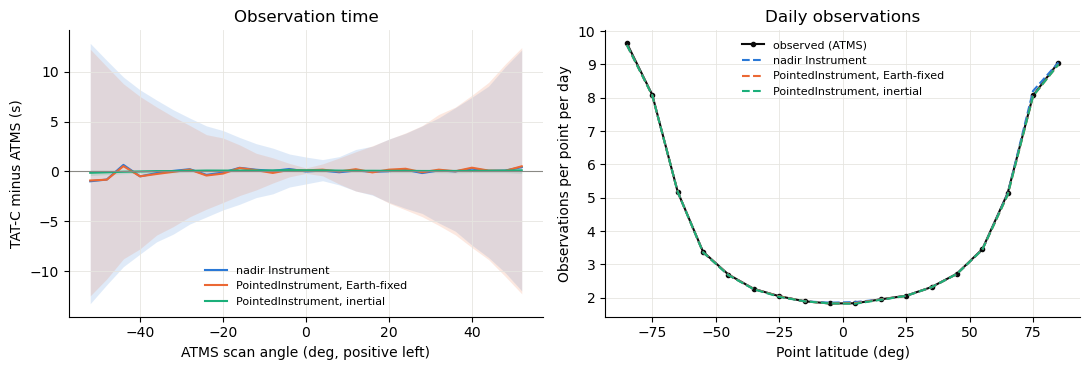

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
edges5 = np.arange(-54, 55, 4)
for (name, matched), color in zip(matched5.items(), [BLUE, ORANGE, AQUA]):
    hit = matched.epoch.notna()
    dt = (matched.epoch - matched.time).dt.total_seconds()
    q = binned(matched.scan_angle[hit].to_numpy(), dt[hit].to_numpy(), edges5)
    axes[0].fill_between((edges5[:-1] + edges5[1:]) / 2, q[:, 0], q[:, 2], color=color, alpha=0.15, lw=0)
    axes[0].plot((edges5[:-1] + edges5[1:]) / 2, q[:, 1], color=color, label=name)
axes[0].axhline(0, color=GRAY, lw=0.8)
axes[0].set(xlabel="ATMS scan angle (deg, positive left)", ylabel="TAT-C minus ATMS (s)", title="Observation time")
axes[0].legend(frameon=False, fontsize=8)
lat_edges = np.arange(-90, 91, 10)
point_lat = points5.geometry.y.to_numpy()
n_points = np.histogram(point_lat, lat_edges)[0]
axes[1].plot((lat_edges[:-1] + lat_edges[1:]) / 2, np.histogram(point_lat[observed5.point_id], lat_edges)[0] / n_points, color=INK, marker="o", ms=3, label="observed (ATMS)")
for (name, predicted), color in zip(predicted5.items(), [BLUE, ORANGE, AQUA]):
    axes[1].plot((lat_edges[:-1] + lat_edges[1:]) / 2, np.histogram(point_lat[predicted.point_id.astype(int)], lat_edges)[0] / n_points, color=color, ls="--", label=name)
axes[1].set(xlabel="Point latitude (deg)", ylabel="Observations per point per day", title="Daily observations")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

All three instruments predict the observed passes almost one for one (more than 99% matched), from about 2 observations per day at the equator to more than 9 near the poles. The few unmatched passes are at the swath edges (Test 4).

The observation times differ. The nadir `Instrument` reports the time of closest approach, which is up to about 12 s (95th percentile) from the time ATMS actually scans a point near the swath edges, because the scan line is rotated from the perpendicular to the ground track (Test 2). A `PointedInstrument` in the Earth-fixed frame has the same offset. In the inertial frame, TAT-C's epochs match the actual scan times to within 0.26 s (95th percentile), and the elevation angles at those times to within 0.02 deg.

## Summary

| Test | Result |
| --- | --- |
| 1. Orbit (operational TLE vs. reported position) | 1.1 km along track (95th percentile), 0.4 km or better radially and cross-track |
| 2. Scan geometry | scan plane perpendicular to the *inertial* velocity (within 0.06 deg); Earth-fixed velocity off by up to 4 deg; effective spacing 1.112 deg and roll 0.05 deg vs. nominal 1.11 deg |
| 3. Beam geolocation (`collect_ground_pixels`) | up to 90 km along track at the edges with the default Earth-fixed frame; about 5 km with the inertial frame (scan timing); 0.7 km median with fitted scan angles and per-beam sample times |
| 4. Swath (`compute_ground_track`) | swath width 11 km narrow with the nominal field of regard, within 2 km with the measured one; one-orbit IoU 0.99 for time steps from 8/3 to 128 s |
| 5. Daily observations (`collect_observations`) | more than 99% of passes matched for all instruments; epochs within 0.26 s (95th percentile) for an inertial-frame `PointedInstrument`, vs. 11 s for a nadir `Instrument` |

**Along-track reference direction.** The largest difference between TAT-C's default imager geometry and ATMS is the orientation of the scan. Like most Earth observation spacecraft without yaw steering, NOAA-20 keeps its attitude aligned with the orbit plane, so the scan is perpendicular to the inertial velocity, while TAT-C's default view is perpendicular to the ground track (the Earth-fixed velocity, as for a yaw-steered spacecraft). Setting `velocity_frame=VelocityFrame.INERTIAL` on a `PointedInstrument` removes along-track errors of up to 90 km at the swath edges and observation time errors of about 10 s.

**Scan timing.** TAT-C observes all pixels of a view at one instant, whereas ATMS sweeps its 96 beams over about 1.7 s. The resulting along-track error, about 4.5 km at the swath edges, is a fraction of an ATMS footprint and of the 17.6 km between scans. For coverage, the along-track field of view stands in for the scan: tailored to the time step, consecutive views tile the swath at time steps from one scan to two minutes.

**Instrument parameters.** Nominal scan angles produce a swath about 11 km narrower than observed; the effective spacing and roll fitted from the geolocation close the gap. For a nadir `Instrument`, the swath width also depends on the satellite's altitude, which varies by about 30 km over NOAA-20's orbit (mostly from Earth's oblateness). `collect_observations` refines its access periods to the times when a point's angle from nadir equals half the field of regard, so they follow the actual altitude (an earlier approximation, a minimum elevation angle at the apogee radius minus the mean Earth radius, narrowed the swath at middle and high latitudes and missed 37 rather than 22 observed passes).

**Changes to TAT-C.** This validation led to the `velocity_frame` option and exposed two problems with the rectangular `PointedInstrument`, which have been fixed: rectangular footprint polygons for wide, elongated views were inaccurate (misplaced corners and too few points along the long sides), and `collect_observations` checked a pointed instrument's view only at the midpoint of each access period, missing up to 77% of observations for a view tailored to a scan period. It now checks the view at the time the view sweeps over the point and reports that time as the epoch.